## Importing Necessary Libraries and Data

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

import pandas
import numpy
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import gc
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import (
    TrainingArguments, 
    AutoTokenizer, 
    AutoModelForSeq2SeqLM, 
    Seq2SeqTrainer, 
    Seq2SeqTrainingArguments, 
    DataCollatorForSeq2Seq, 
    BertTokenizer, 
    BertForSequenceClassification
)
from transformers.trainer import Trainer
from trl import PPOConfig, PPOTrainer, AutoModelForSeq2SeqLMWithValueHead # future scope
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, ConfusionMatrixDisplay, classification_report
from torch.utils.data import Dataset
import evaluate

## Phase 1: Generating Multiple summaries and simulating preference

### Using the pre-trained model from facebook BART

In [2]:
# working on a subset of the dataset for testing purpose

dataset = load_dataset("cnn_dailymail", "3.0.0")
train_data_bart = dataset["train"].select(range(1000))
val_data_bart = dataset["validation"].select(range(200))

# defining rouge metrics

rouge = evaluate.load('rouge')

In [3]:
# loading tokenizer and model

model_name = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).cuda()

In [4]:
# preprocessing 

def preprocess_bart(example):
    model_inputs = tokenizer(
        example["article"],
        max_length=512,
        truncation=True,
        padding="max_length"
    )
    
    # Tokenize the target summary using the target tokenizer context
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            example["highlights"],
            max_length=128,
            truncation=True,
            padding="max_length"
        )

    # Replace pad token ids in labels with -100 (ignored in loss)
    labels["input_ids"] = [
        (label if label != tokenizer.pad_token_id else -100)
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train_bart = train_data_bart.map(preprocess_bart, batched=True, remove_columns=train_data_bart.column_names)
tokenized_val_bart = val_data_bart.map(preprocess_bart, batched=True, remove_columns=val_data_bart.column_names)

Map: 100%|██████████| 200/200 [00:00<00:00, 2092.26 examples/s]


In [ ]:
# evaluation metrics
def compute_metrics_bart(eval_preds):
    preds, labels = eval_preds

    # Step 1: Replace -100 with pad_token_id for each prediction sequence
    cleaned_preds = [
        [token if token != -100 else tokenizer.pad_token_id for token in pred]
        for pred in preds
    ]
    decoded_preds = tokenizer.batch_decode(cleaned_preds, skip_special_tokens=True)

    # Step 2: Remove -100 from labels before decoding
    cleaned_labels = [
        [token for token in label if token != -100]
        for label in labels
    ]
    decoded_labels = tokenizer.batch_decode(cleaned_labels, skip_special_tokens=True)

    # Compute ROUGE scores
    return rouge.compute(predictions=decoded_preds, references=decoded_labels)

In [6]:
# training the BART model

training_args = Seq2SeqTrainingArguments(
    output_dir="./model_output",
    logging_dir="./logs_tensorboard",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    eval_strategy='epoch',
    num_train_epochs=1,
    predict_with_generate=True,
    save_total_limit=2,
    logging_steps=50,
    report_to="tensorboard"
)

trainer_bart = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_bart,
    eval_dataset=tokenized_val_bart,
    tokenizer=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
    compute_metrics=compute_metrics_bart
)

trainer_bart.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,0.674100,0.630796,0.327381,0.138178,0.233683,0.302519


TrainOutput(global_step=500, training_loss=0.8314182815551758, metrics={'train_runtime': 4688.2129, 'train_samples_per_second': 0.213, 'train_steps_per_second': 0.107, 'total_flos': 1083552301056000.0, 'train_loss': 0.8314182815551758, 'epoch': 1.0})

In [7]:
# defining a function to simulate multiple summaries

def generate_bart_summaries(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to("cuda")
    greedy = model.generate(inputs["input_ids"], max_length=128)
    beam = model.generate(inputs["input_ids"], max_length=128, num_beams=4, early_stopping=True)
    return (
        tokenizer.decode(greedy[0], skip_special_tokens=True),
        tokenizer.decode(beam[0], skip_special_tokens=True)
    )

sample_article = val_data_bart[0]["article"]
greedy_bart, beam_bart = generate_bart_summaries(sample_article)
print("🧠 BART - Greedy:\n", greedy_bart)
print("🚀 BART - Beam:\n", beam_bart)

🧠 BART - Greedy:
 Zully Broussard donated one of her kidneys to a stranger .
Big data paired up with her generosity resulted in six patients receiving transplants .
"That surprised and surprised me," she says .
Her generosity paired with big data led to her generosity being recognized .
🚀 BART - Beam:
 Zully Broussard donated one of her kidneys to a stranger .
Big data paired up with her generosity resulted in six patients receiving transplants .
"That surprised and surprised me," she says .
Her generosity paired with big data led to her generosity being recognized .


rouge1: 0.3287
rouge2: 0.1369
rougeL: 0.2363
rougeLsum: 0.3037


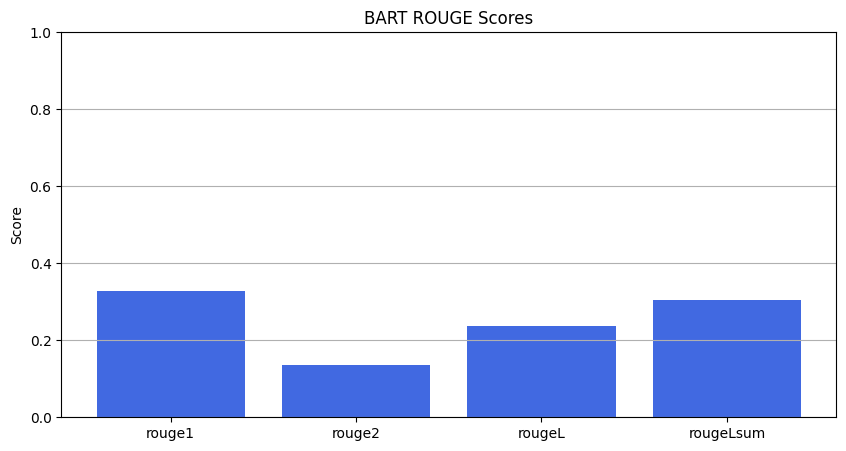

In [8]:
# visualizing Evaluation (ROUGE score)

generated_ids_all = []
label_ids_all = []

# Loop through validation samples safely
for i in range(len(tokenized_val_bart)):
    torch.cuda.empty_cache()
    gc.collect()
    input_ids = torch.tensor(tokenized_val_bart[i]["input_ids"]).unsqueeze(0).to("cuda")
    label_ids = tokenized_val_bart[i]["labels"]

    # Skip invalid samples
    if all([l == -100 for l in label_ids]):
        continue

    with torch.no_grad():
        generated_ids = model.generate(input_ids, max_new_tokens=64)
        generated_ids_all.append(generated_ids[0].cpu().numpy())
        label_ids_all.append(numpy.array(label_ids))


# Call the evaluation function
bart_rouge_scores = compute_metrics_bart((generated_ids_all, label_ids_all))

# Print scores
for metric, score in bart_rouge_scores.items():
    print(f"{metric}: {score:.4f}")

labels = list(bart_rouge_scores.keys())
values = list(bart_rouge_scores.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='royalblue')
plt.title("BART ROUGE Scores")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

In [9]:
# using ROUGE score based preference for making a choice between summaries 

def choose_best_summary(summary_greedy, summary_beam, reference_summary, model_name="BART"):
    result_greedy = rouge.compute(predictions=[summary_greedy], references=[reference_summary])
    result_beam = rouge.compute(predictions=[summary_beam], references=[reference_summary])
    
    score_greedy = result_greedy["rougeL"]
    score_beam = result_beam["rougeL"]
    
    print(f"\n📊 {model_name} | ROUGE-L (Greedy): {score_greedy:.4f} | ROUGE-L (Beam): {score_beam:.4f}")
    
    if score_beam > score_greedy:
        print("✅ Preferred: Beam Summary\n")
        return summary_beam, "beam"
    else:
        print("✅ Preferred: Greedy Summary\n")
        return summary_greedy, "greedy"

reference = val_data_bart[0]["highlights"]
best_summary_bart, method_bart = choose_best_summary(greedy_bart, beam_bart, reference)


📊 BART | ROUGE-L (Greedy): 0.2462 | ROUGE-L (Beam): 0.2462
✅ Preferred: Greedy Summary



In [ ]:
# converting the result to pandas dataframe

# Number of samples to process
N = 200 
all_bart_results = []

for i in tqdm(range(N)):
    article = val_data_bart[i]["article"]
    reference = val_data_bart[i]["highlights"]

    # Generate summaries
    greedy, beam = generate_bart_summaries(article)

    # Choose best summary based on ROUGE
    best_summary, preferred_method = choose_best_summary(greedy, beam, reference, model_name="BART")

    # Optional: Compute ROUGE scores for both
    result_greedy = rouge.compute(predictions=[greedy], references=[reference])
    result_beam = rouge.compute(predictions=[beam], references=[reference])

    # Store all data
    all_bart_results.append({
        "model": "BART",
        "index": i,
        "preferred_method": preferred_method,
        "reference_summary": reference,
        "preferred_summary": best_summary,
        "greedy_summary": greedy,
        "beam_summary": beam,
        "rougeL_greedy": result_greedy["rougeL"],
        "rougeL_beam": result_beam["rougeL"]
    })

# Convert to DataFrame
df_bart_summaries = pandas.DataFrame(all_bart_results)

# Show the DataFrame
df_bart_summaries.head()

  0%|          | 1/200 [00:01<05:25,  1.63s/it]


📊 BART | ROUGE-L (Greedy): 0.2462 | ROUGE-L (Beam): 0.2462
✅ Preferred: Greedy Summary



  1%|          | 2/200 [00:03<05:44,  1.74s/it]


📊 BART | ROUGE-L (Greedy): 0.0750 | ROUGE-L (Beam): 0.0750
✅ Preferred: Greedy Summary



  2%|▏         | 3/200 [00:05<06:19,  1.93s/it]

...

100%|█████████▉| 199/200 [05:50<00:01,  1.75s/it]


📊 BART | ROUGE-L (Greedy): 0.2105 | ROUGE-L (Beam): 0.2105
✅ Preferred: Greedy Summary



100%|██████████| 200/200 [05:52<00:00,  1.76s/it]


📊 BART | ROUGE-L (Greedy): 0.1905 | ROUGE-L (Beam): 0.1905
✅ Preferred: Greedy Summary



,model,index,preferred_method,reference_summary,preferred_summary,greedy_summary,beam_summary,rougeL_greedy,rougeL_beam
0,BART,0,greedy,Zully Broussard decided to give a kidney to a ...,Zully Broussard donated one of her kidneys to ...,Zully Broussard donated one of her kidneys to ...,Zully Broussard donated one of her kidneys to ...,0.246154,0.246154
1,BART,1,greedy,The 20th MLS season begins this weekend .\nLea...,San Jose Clash and DC United played the first ...,San Jose Clash and DC United played the first ...,San Jose Clash and DC United played the first ...,0.075000,0.075000
2,BART,2,greedy,Bafetimbi Gomis collapses within 10 minutes of...,French striker Bafetimbi Gomis says he is now ...,French striker Bafetimbi Gomis says he is now ...,French striker Bafetimbi Gomis says he is now ...,0.265060,0.265060
3,BART,3,greedy,Rory McIlroy throws club into water at WGC Cad...,Rory McIlroy pulls his second shot on the eigh...,Rory McIlroy pulls his second shot on the eigh...,Rory McIlroy pulls his second shot on the eigh...,0.200000,0.200000
4,BART,4,greedy,"Cayman Naib, 13, hasn't been heard from since ...","Cayman Naib, 13, has been missing since Wednes...","Cayman Naib, 13, has been missing since Wednes...","Cayman Naib, 13, has been missing since Wednes...",0.218750,0.218750


In [11]:
df_bart_summaries.to_csv('bart_summaries', index=False)

## Phase 2: Training a BERT model to classify preferred given article

In [12]:
df = pandas.read_csv("bart_summaries", sep=',')

In [ ]:
# Attach article content using the stored index
df["article"] = df["index"].apply(lambda i: val_data_bart[int(i)]["article"])

In [14]:
reward_data = []

for _, row in df.iterrows():
    article = row["article"]
    greedy = row["greedy_summary"]
    beam = row["beam_summary"]
    preferred = row["preferred_method"]

    if preferred == "greedy":
        reward_data.append({"text": f"{article} [SEP] {greedy}", "label": 1})
        reward_data.append({"text": f"{article} [SEP] {beam}", "label": 0})
    else:
        reward_data.append({"text": f"{article} [SEP] {beam}", "label": 1})
        reward_data.append({"text": f"{article} [SEP] {greedy}", "label": 0})

df_reward = pandas.DataFrame(reward_data)

In [15]:
df_reward.to_csv("bart_reward_dataset.csv", index=False)

In [16]:
# Split into 80% train, 20% validation
train_texts, val_texts = train_test_split(df_reward, test_size=0.2, random_state=42)

train_sentences = list(train_texts["text"])
train_labels = list(train_texts["label"])

val_sentences = list(val_texts["text"])
val_labels = list(val_texts["label"])

In [17]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize train and validation texts
train_encodings = tokenizer(train_sentences, truncation=True, padding="max_length", max_length=512)
val_encodings = tokenizer(val_sentences, truncation=True, padding="max_length", max_length=512)

In [18]:
# creating a Dataset Class
class RewardDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

# Create Dataset objects
train_dataset = RewardDataset(train_encodings, train_labels)
val_dataset = RewardDataset(val_encodings, val_labels)

In [19]:
# Load base BERT model for binary classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to("cuda")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# defining Training Arguements

training_args = TrainingArguments(
    output_dir="./bert-reward",              # where to save the model
    eval_strategy="epoch",             # evaluate after each epoch
    save_strategy="epoch",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    learning_rate=2e-5,
    logging_dir="./logs_reward",             # TensorBoard logs
    logging_steps=10,
    load_best_model_at_end=True,
    report_to="none",                       
    save_total_limit=1
)

In [21]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.757700,0.709572,0.437500,0.000000,0.000000,0.000000
2,0.685300,0.708308,0.337500,0.285714,0.136364,0.184615
3,0.687900,0.711542,0.325000,0.250000,0.113636,0.156250


TrainOutput(global_step=240, training_loss=0.7052780667940776, metrics={'train_runtime': 1103.4381, 'train_samples_per_second': 0.87, 'train_steps_per_second': 0.218, 'total_flos': 252586613145600.0, 'train_loss': 0.7052780667940776, 'epoch': 3.0})

In [23]:
metrics = trainer.evaluate()
print("📊 Final Evaluation Metrics:", metrics)

📊 Final Evaluation Metrics: {'eval_loss': 0.7083080410957336, 'eval_accuracy': 0.3375, 'eval_precision': 0.2857142857142857, 'eval_recall': 0.13636363636363635, 'eval_f1': 0.18461538461538463, 'eval_runtime': 14.8358, 'eval_samples_per_second': 5.392, 'eval_steps_per_second': 1.348, 'epoch': 3.0}


In [24]:
trainer.save_model("./bert-reward-model")

### Visualizing the model performance

In [25]:
# Convert trainer logs to a DataFrame
log_history = pandas.DataFrame(trainer.state.log_history)

In [26]:
# Logs with loss values during training
train_logs = log_history[log_history["loss"].notnull()]

# Logs after evaluation steps
eval_logs = log_history[log_history["eval_loss"].notnull()]

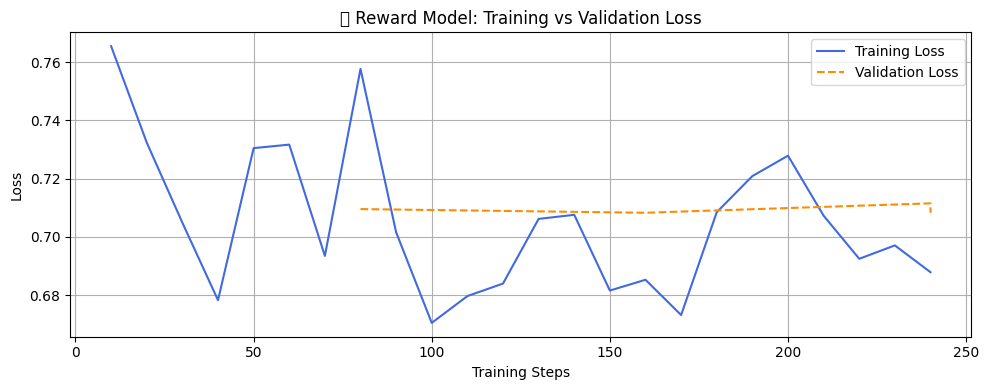

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss", color="royalblue")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss", color="darkorange", linestyle="--")
plt.title("📉 Reward Model: Training vs Validation Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

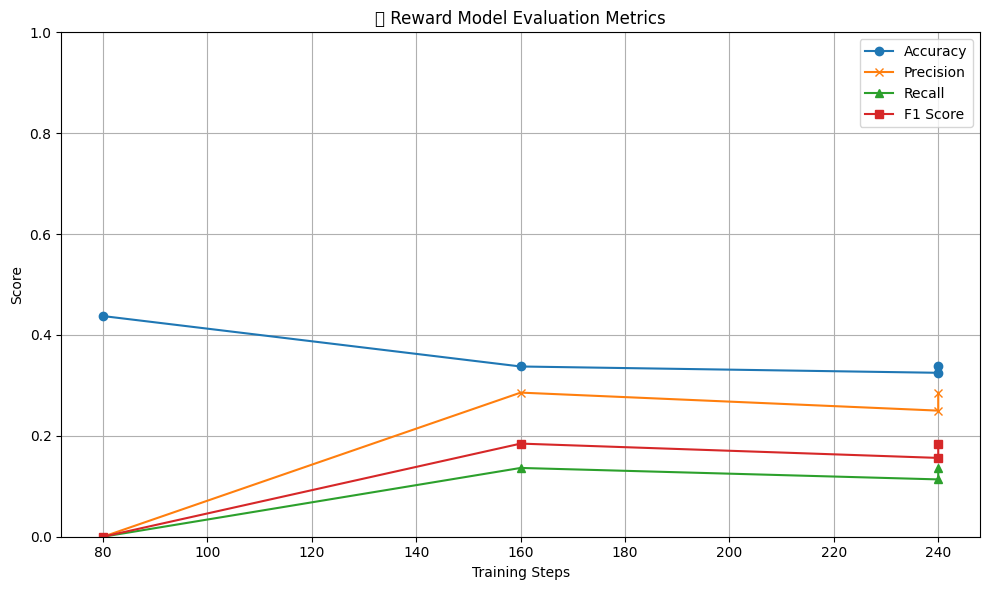

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(eval_logs["step"], eval_logs["eval_accuracy"], label="Accuracy", marker="o")
plt.plot(eval_logs["step"], eval_logs["eval_precision"], label="Precision", marker="x")
plt.plot(eval_logs["step"], eval_logs["eval_recall"], label="Recall", marker="^")
plt.plot(eval_logs["step"], eval_logs["eval_f1"], label="F1 Score", marker="s")

plt.title("📊 Reward Model Evaluation Metrics")
plt.xlabel("Training Steps")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# Use the validation dataset
predictions_output = trainer.predict(val_dataset)

# Extract raw logits
logits = predictions_output.predictions
labels = predictions_output.label_ids

# Get predictions from logits
preds = logits.argmax(axis=-1)


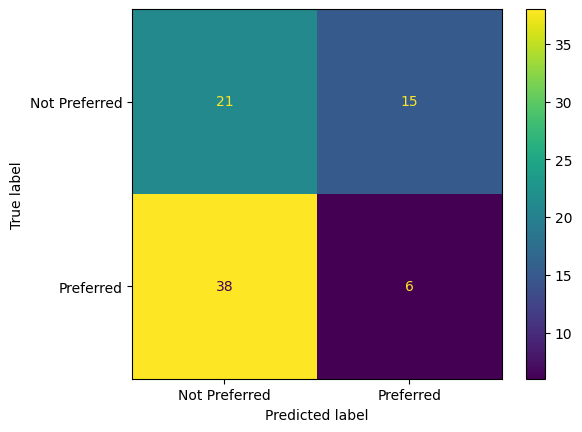

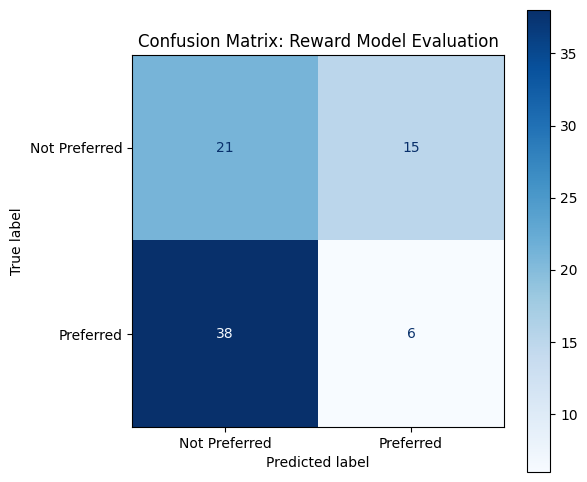


Classification Report:
               precision    recall  f1-score   support

Not Preferred       0.36      0.58      0.44        36
    Preferred       0.29      0.14      0.18        44

     accuracy                           0.34        80
    macro avg       0.32      0.36      0.31        80
 weighted avg       0.32      0.34      0.30        80



In [30]:
disp = ConfusionMatrixDisplay.from_predictions(labels, preds, display_labels=["Not Preferred", "Preferred"])

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap='Blues', ax=ax, colorbar=True)
plt.title("Confusion Matrix: Reward Model Evaluation")
plt.grid(False)
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=["Not Preferred", "Preferred"]))